In [ ]:
import os
import joblib

PROJECT_PATH = '/content/drive/MyDrive/MINI Project ML'

os.makedirs(PROJECT_PATH, exist_ok=True)

print("Project path:", PROJECT_PATH)
print("Drive folder exists:", os.path.exists(PROJECT_PATH))

Project path: /content/drive/MyDrive/MINI Project ML
Drive folder exists: True


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
file_name = "/content/drive/MyDrive/MINI Project ML/mtsamples.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
eda_folder = "/content/drive/MyDrive/MINI Project ML"
os.makedirs(eda_folder, exist_ok=True)

print("EDA folder created:", eda_folder)

EDA folder created: /content/drive/MyDrive/MINI Project ML


In [ ]:
print("========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== FIRST 5 RECORDS ==========")
display(df.head())

print("\n========== STATISTICAL SUMMARY ==========")
display(df.describe(include="all"))

========== DATASET SHAPE ==========
(4999, 6)

========== COLUMN NAMES ==========
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

========== DATA TYPES ==========
Unnamed: 0            int64
description          object
medical_specialty    object
sample_name          object
transcription        object
keywords             object
dtype: object

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB

========== FIRST 5 RECORDS ==

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."



========== STATISTICAL SUMMARY ==========


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
count,4999.000000,4999,4999,4999,4966,3931
unique,NaN,2348,40,2377,2357,3849
top,NaN,An example/template for a routine normal male...,Surgery,Lumbar Discogram,"PREOPERATIVE DIAGNOSIS: , Low back pain.,POSTO...",
freq,NaN,12,1103,5,5,81
mean,2499.000000,NaN,NaN,NaN,NaN,NaN
std,1443.231328,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN
25%,1249.500000,NaN,NaN,NaN,NaN,NaN
50%,2499.000000,NaN,NaN,NaN,NaN,NaN
75%,3748.500000,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


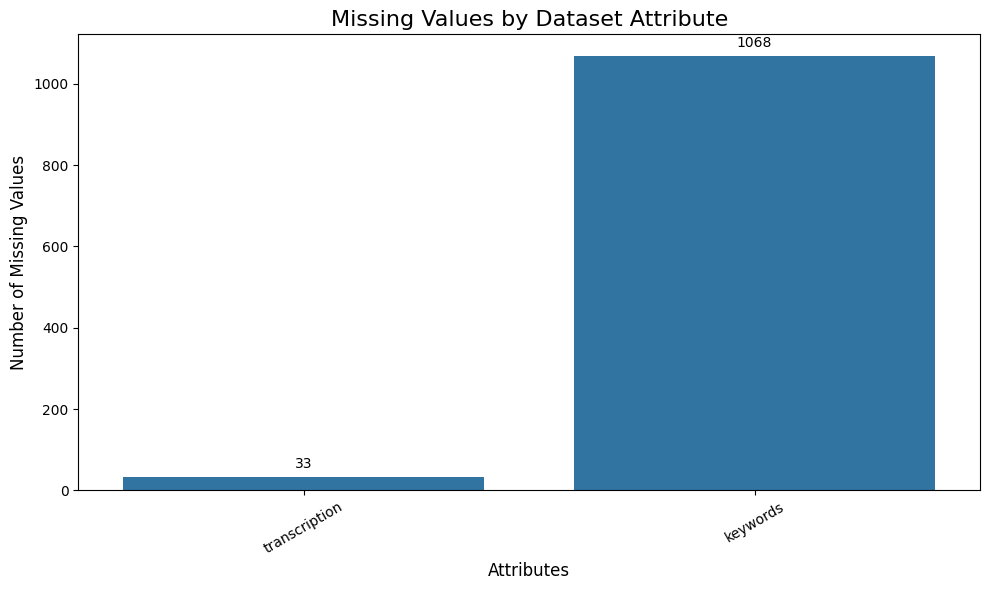

In [ ]:
plt.figure(figsize=(10, 6))

missing_plot = missing_values[missing_values > 0]

if len(missing_plot) > 0:
    ax = sns.barplot(
        x=missing_plot.index,
        y=missing_plot.values
    )

    plt.title("Missing Values by Dataset Attribute", fontsize=16)
    plt.xlabel("Attributes", fontsize=12)
    plt.ylabel("Number of Missing Values", fontsize=12)
    plt.xticks(rotation=30)

    for i, value in enumerate(missing_plot.values):
        ax.text(i, value + max(missing_plot.values) * 0.02,
                str(value), ha="center")

    plt.tight_layout()

    plt.savefig(
        f"{eda_folder}/01_missing_values.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
else:
    print("No missing values found.")

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [ ]:
specialty_counts = df["medical_specialty"].value_counts()

print("Number of unique medical specialties:",
      df["medical_specialty"].nunique())

display(specialty_counts)

Number of unique medical specialties: 40


,count
medical_specialty,
Surgery,1103
Consult - History and Phy.,516
Cardiovascular / Pulmonary,372
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,230
Neurology,223
SOAP / Chart / Progress Notes,166


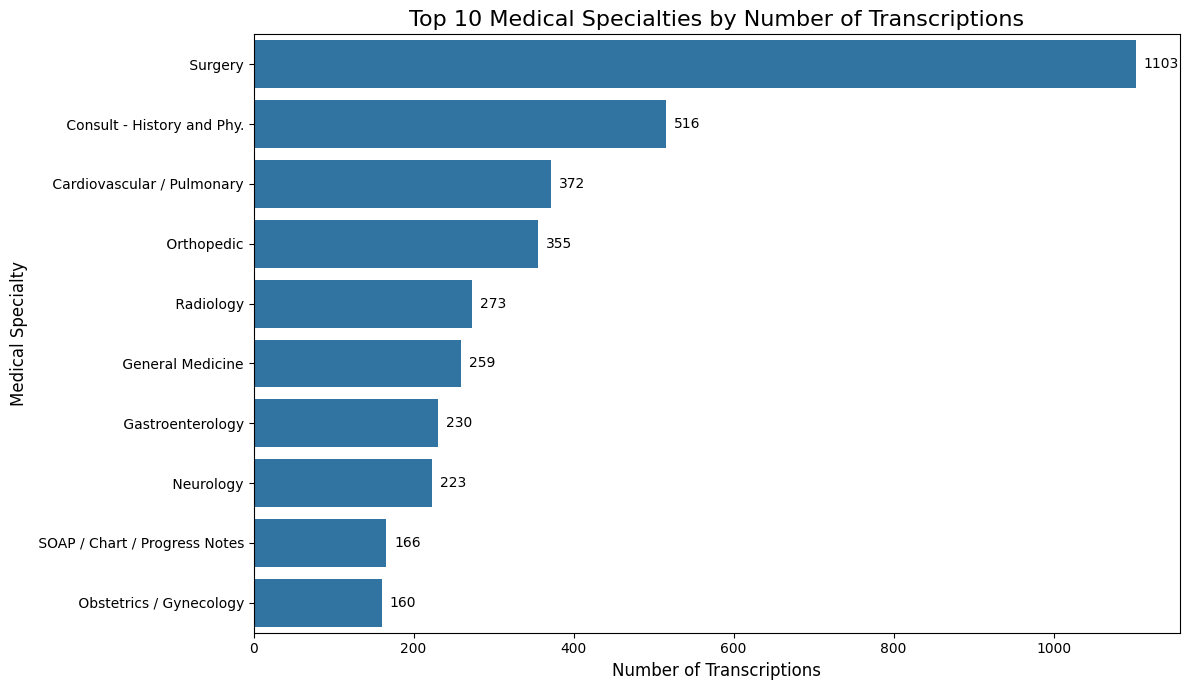

In [ ]:
top10 = specialty_counts.head(10)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Medical Specialties by Number of Transcriptions",
          fontsize=16)
plt.xlabel("Number of Transcriptions", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)

for i, value in enumerate(top10.values):
    ax.text(
        value + 10,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/02_top10_medical_specialties.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

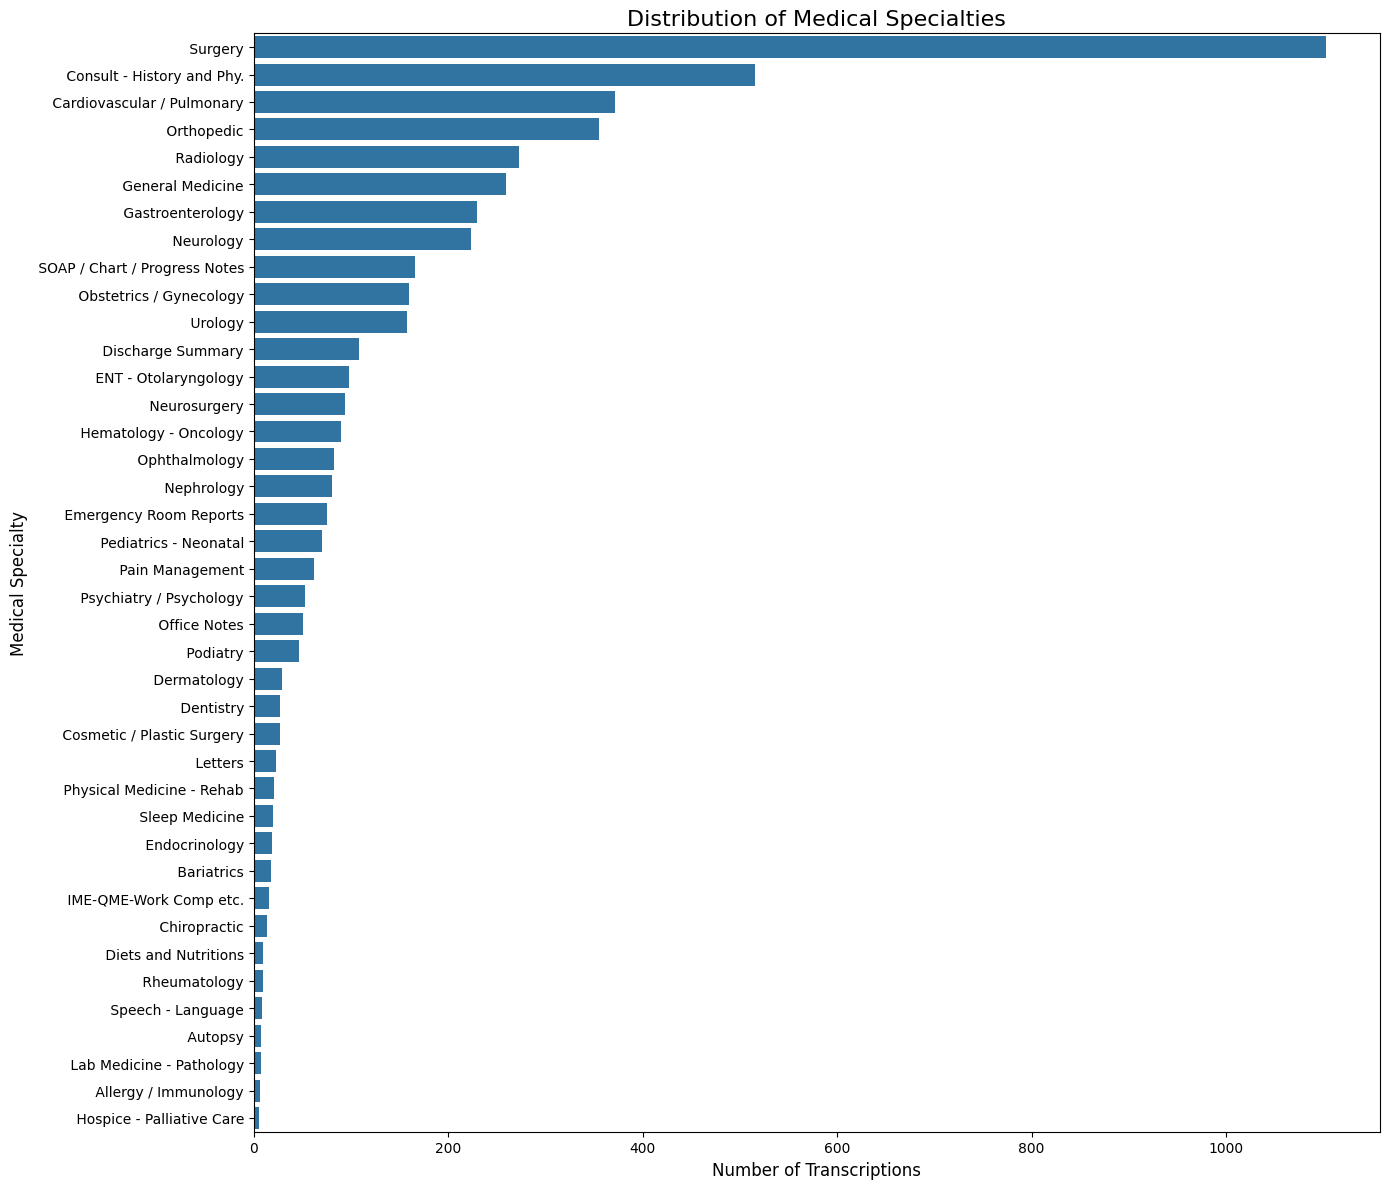

In [ ]:
plt.figure(figsize=(14, 12))

ax = sns.barplot(
    x=specialty_counts.values,
    y=specialty_counts.index
)

plt.title("Distribution of Medical Specialties",
          fontsize=16)

plt.xlabel("Number of Transcriptions", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/03_complete_specialty_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
df["transcription_length"] = (
    df["transcription"]
    .fillna("")
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print(df["transcription_length"].describe())

count    4999.000000
mean      462.376275
std       317.585206
min         0.000000
25%       239.000000
50%       397.000000
75%       614.000000
max      3029.000000
Name: transcription_length, dtype: float64


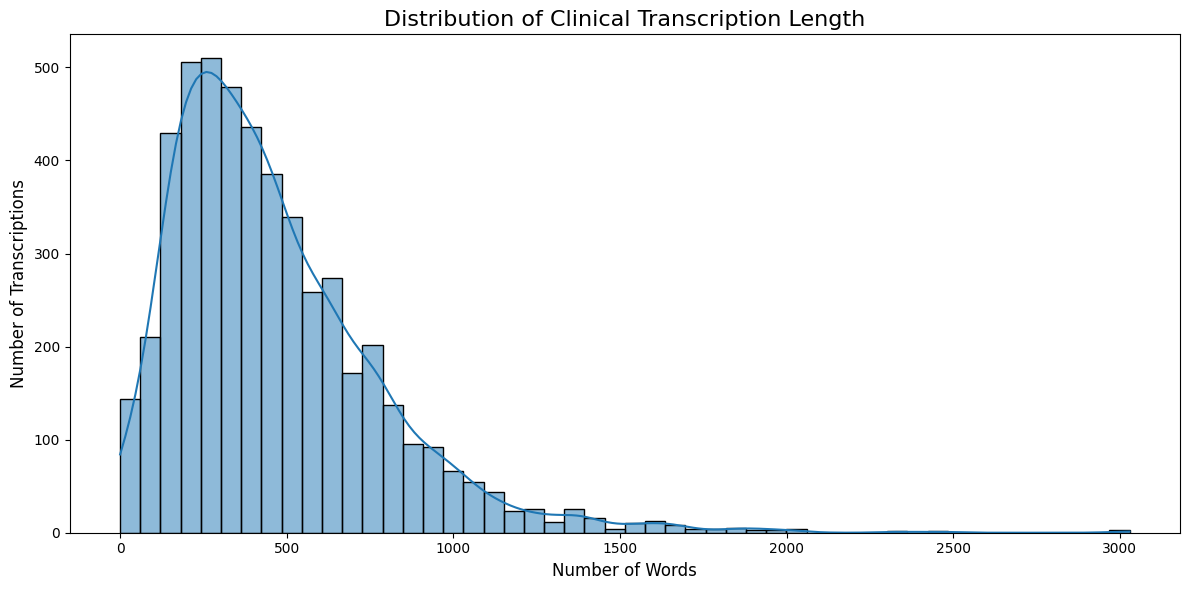

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["transcription_length"],
    bins=50,
    kde=True
)

plt.title("Distribution of Clinical Transcription Length",
          fontsize=16)

plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Number of Transcriptions", fontsize=12)

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/04_transcription_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

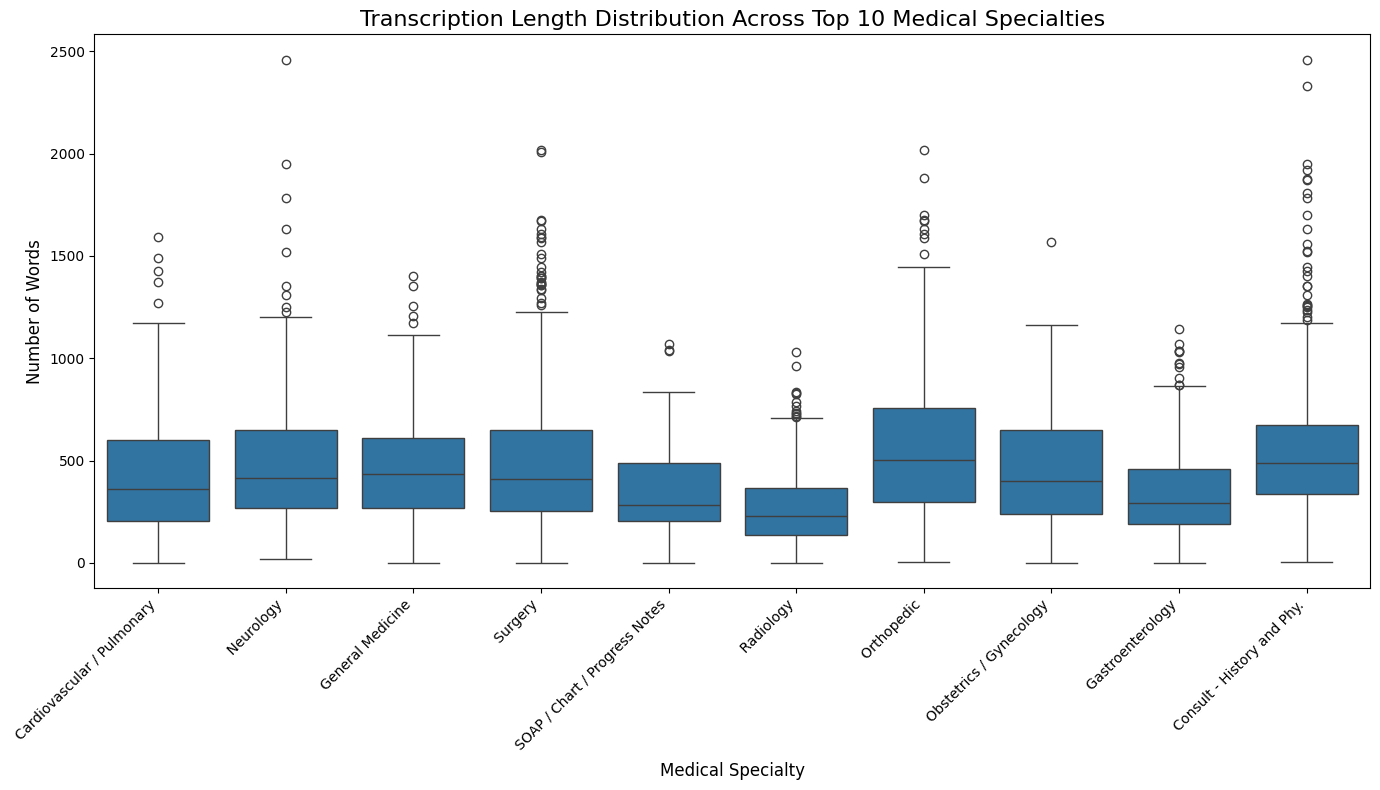

In [ ]:
top_specialties = specialty_counts.head(10).index

plot_df = df[
    df["medical_specialty"].isin(top_specialties)
].copy()

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=plot_df,
    x="medical_specialty",
    y="transcription_length"
)

plt.title("Transcription Length Distribution Across Top 10 Medical Specialties",
          fontsize=16)

plt.xlabel("Medical Specialty", fontsize=12)
plt.ylabel("Number of Words", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/05_transcription_length_by_specialty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!pip install wordcloud -q

In [ ]:
from wordcloud import WordCloud, STOPWORDS

text_data = df["transcription"].dropna().astype(str)

all_text = " ".join(text_data)

print("Total characters used for word cloud:", len(all_text))

Total characters used for word cloud: 15162758


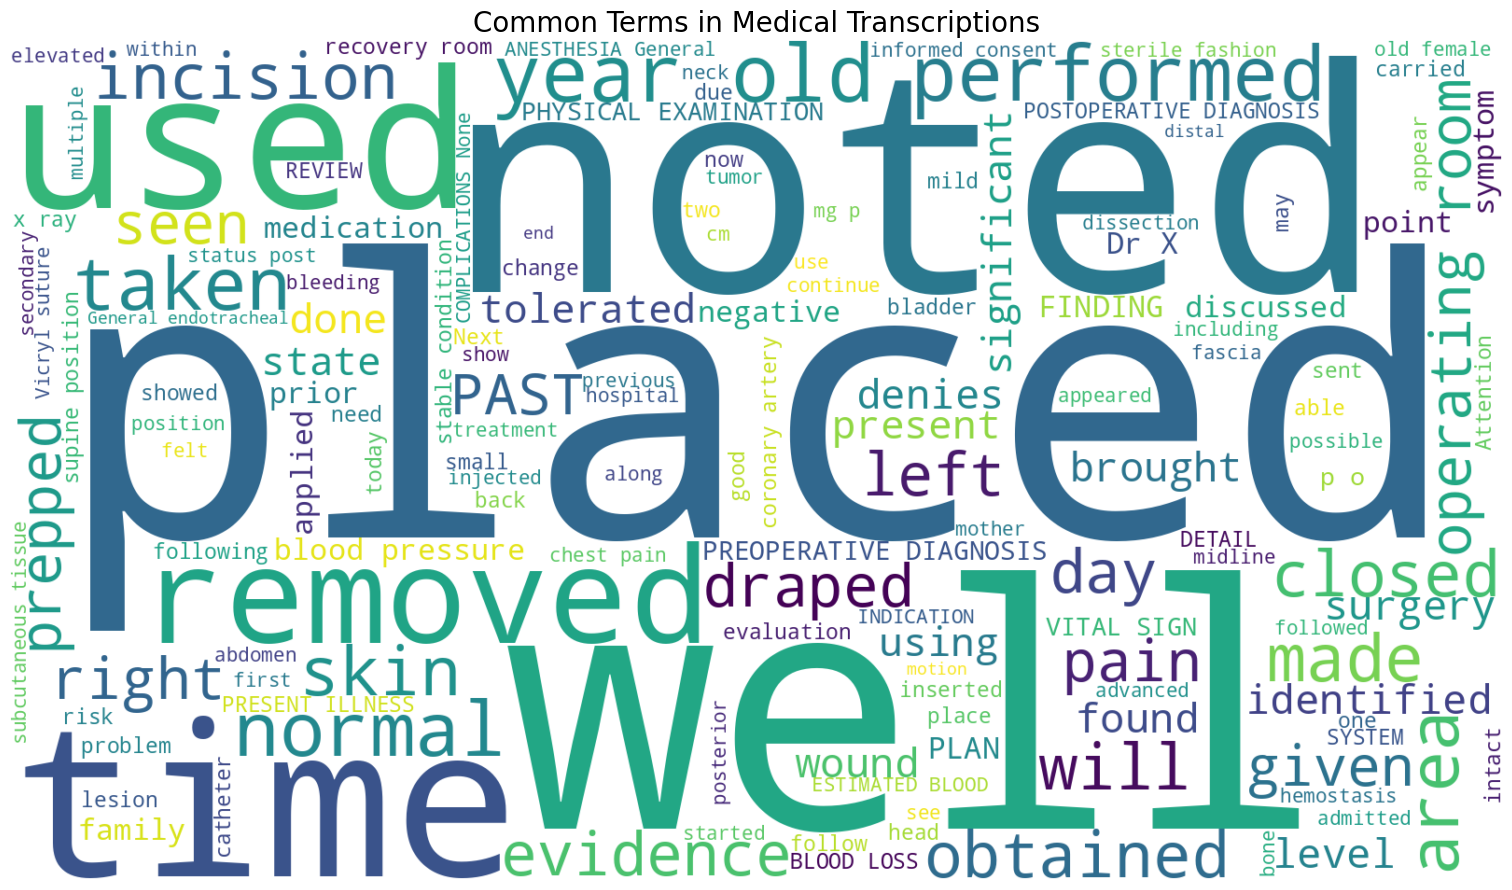

In [ ]:
custom_stopwords = set(STOPWORDS)

# Add common non-informative words if needed
custom_stopwords.update([
    "patient",
    "patients",
    "history",
    "medical",
    "procedure",
    "report"
])

wordcloud = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    stopwords=custom_stopwords,
    max_words=150
).generate(all_text)

plt.figure(figsize=(16, 9))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title(
    "Common Terms in Medical Transcriptions",
    fontsize=20
)

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/06_medical_transcription_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
os.listdir(eda_folder)

['MiniProject EDA analysis.ipynb',
 'MiniProject  Data Preprocessing.ipynb',
 'MiniProject_TFIDF_Feature_Extraction.ipynb',
 'mtsamples.csv',
 'EDA_Diagrams.zip',
 '06_medical_transcription_wordcloud.png',
 'preprocessed_mtsamples.csv',
 'tfidf_vectorizer.pkl',
 'X_train_tfidf.pkl',
 'X_test_tfidf.pkl',
 'y_train.pkl',
 'y_test.pkl',
 '01_missing_values.png',
 '02_top10_medical_specialties.png',
 '03_complete_specialty_distribution.png',
 '04_transcription_length_distribution.png',
 '05_transcription_length_by_specialty.png',
 'MiniProject_Model_Training.ipynb.ipynb']

👆Up to Week 6 For Sprint release 1

#   Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MINI Project ML/mtsamples.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
data = df[['transcription', 'medical_specialty']].copy()

print("Selected Dataset Shape:", data.shape)
data.head()

Selected Dataset Shape: (4999, 2)


,transcription,medical_specialty
0,"SUBJECTIVE:, This 23-year-old white female pr...",Allergy / Immunology
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",Bariatrics
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",Bariatrics
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",Cardiovascular / Pulmonary
4,1. The left ventricular cavity size and wall ...,Cardiovascular / Pulmonary


In [ ]:
print(data.isnull().sum())

transcription        33
medical_specialty     0
dtype: int64


Remove missing records

In [ ]:
data = data.dropna(subset=['transcription', 'medical_specialty'])

print("Shape after removing missing values:", data.shape)

Shape after removing missing values: (4966, 2)


Check duplicates

In [ ]:
print("Duplicate records:", data.duplicated().sum())

Duplicate records: 2


Then remove them:

In [ ]:
data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (4964, 2)


Create text preprocessing function

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

Test preprocessing on one record

In [ ]:
sample_text = data['transcription'].iloc[0]

print("Original Text:")
print(sample_text)

print("\nPreprocessed Text:")
print(preprocess_text(sample_text))

Original Text:
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appear to be working very well.  She has used over-the-counter sprays but no prescription nasal sprays.  She does have asthma but doest not require daily medication for this and does not think it is flaring up.,MEDICATIONS: , Her only medication currently is Ortho Tri-Cyclen and the Allegra.,ALLERGIES: , She has no known medicine allergies.,OBJECTIVE:,Vitals:  Weight was 130 pounds and blood pressure 124/78.,HEENT:  Her throat was mildly erythematous without exudate.  Nasal mucosa was erythematous and swollen.  Only clear drainage was seen.  TMs were clear.,Neck:  Supple withou

Apply preprocessing

In [ ]:
data['cleaned_transcription'] = data['transcription'].apply(preprocess_text)

data.head()

,transcription,medical_specialty,cleaned_transcription
0,"SUBJECTIVE:, This 23-year-old white female pr...",Allergy / Immunology,subjective year old white female present compl...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",Bariatrics,past medical history difficulty climbing stair...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",Bariatrics,history present illness seen abc today pleasan...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",Cardiovascular / Pulmonary,mode left atrial enlargement left atrial diame...
4,1. The left ventricular cavity size and wall ...,Cardiovascular / Pulmonary,left ventricular cavity size wall thickness ap...


Compare original and cleaned text

In [ ]:
comparison = data[['transcription', 'cleaned_transcription']].head(3)

comparison

,transcription,cleaned_transcription
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective year old white female present compl...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history difficulty climbing stair...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history present illness seen abc today pleasan...


Checking the processed dataset

In [ ]:
print("Dataset Shape:", data.shape)
print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape: (4964, 3)

Missing Values:
transcription            0
medical_specialty        0
cleaned_transcription    0
dtype: int64


Check processed text length

In [ ]:
data['cleaned_length'] = data['cleaned_transcription'].apply(lambda x: len(x.split()))

print(data['cleaned_length'].describe())

count    4964.000000
mean      275.788276
std       177.341015
min         1.000000
25%       146.000000
50%       244.000000
75%       361.000000
max      1674.000000
Name: cleaned_length, dtype: float64


Remove empty processed texts

In [ ]:
data = data[data['cleaned_transcription'].str.strip() != '']

print("Final Preprocessed Shape:", data.shape)

Final Preprocessed Shape: (4964, 4)


Save the cleaned dataset

In [ ]:
data.to_csv('/content/drive/MyDrive/MINI Project ML/preprocessed_mtsamples.csv', index=False)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


TF-IDF Feature Extraction

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

Load the Preprocessed Dataset

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/MINI Project ML/preprocessed_mtsamples.csv')

data.head()

,transcription,medical_specialty,cleaned_transcription,cleaned_length
0,"SUBJECTIVE:, This 23-year-old white female pr...",Allergy / Immunology,subjective year old white female present compl...,117
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",Bariatrics,past medical history difficulty climbing stair...,239
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",Bariatrics,history present illness seen abc today pleasan...,437
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",Cardiovascular / Pulmonary,mode left atrial enlargement left atrial diame...,50
4,1. The left ventricular cavity size and wall ...,Cardiovascular / Pulmonary,left ventricular cavity size wall thickness ap...,157


In [ ]:
print("Dataset Shape:", data.shape)

Dataset Shape: (4964, 4)


Define X and y

In [ ]:
X = data['cleaned_transcription']
y = data['medical_specialty']

print("Features:", X.name)
print("Target:", y.name)

Features: cleaned_transcription
Target: medical_specialty


Stratified 80:20 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3971
Testing samples: 993


Create TF-IDF Vectorizer

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm='l2'
)

print("TF-IDF Vectorizer created successfully.")

TF-IDF Vectorizer created successfully.


Fit TF-IDF on Training Data

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)

print("TF-IDF fitted on training data.")
print("Training TF-IDF Shape:", X_train_tfidf.shape)

TF-IDF fitted on training data.
Training TF-IDF Shape: (3971, 310298)


Transform Test Data

In [ ]:
X_test_tfidf = tfidf.transform(X_test)

print("Test TF-IDF Shape:", X_test_tfidf.shape)

Test TF-IDF Shape: (993, 310298)


Check Number of Features

In [ ]:
print("Number of TF-IDF Features:", len(tfidf.get_feature_names_out()))

Number of TF-IDF Features: 310298


View Sample Feature Names

In [ ]:
feature_names = tfidf.get_feature_names_out()

print("First 50 TF-IDF Features:")
print(feature_names[:50])

First 50 TF-IDF Features:
['aa' 'aa body' 'aa dart' 'aa femoral' 'aa meeting' 'aa periodic'
 'aa present' 'aa trial' 'aaaa' 'aaaa call' 'ab' 'ab antibody' 'ab cd'
 'ab menstrual' 'ab negative' 'abadeedleedlebadle'
 'abadeedleedlebadle repetition' 'abandoned' 'abandoned attention'
 'abandoned done' 'abandoned mother' 'abandoned patient'
 'abandoned procedure' 'abandoned unstable' 'abandoned upcoming'
 'abandoned use' 'abandonment' 'abandonment patient' 'abated'
 'abated past' 'abbott' 'abbott northwestern' 'abbreviated'
 'abbreviated scale' 'abc' 'abc abc' 'abc abcd' 'abc admitted'
 'abc advised' 'abc also' 'abc anterior' 'abc apparently' 'abc appeared'
 'abc applied' 'abc area' 'abc arrived' 'abc asking' 'abc attempted'
 'abc avenue' 'abc avid']


View TF-IDF Values for One Document

In [ ]:
print("TF-IDF values for first training document:")
print(X_train_tfidf[0])

TF-IDF values for first training document:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 333 stored elements and shape (1, 310298)>
  Coords	Values
  (0, 224438)	0.0266890329710261
  (0, 55869)	0.030678640778033714
  (0, 20889)	0.05601302085059791
  (0, 244558)	0.023700205398018644
  (0, 196430)	0.016587913381246475
  (0, 227617)	0.04020884677758181
  (0, 33826)	0.054444804892511085
  (0, 288442)	0.05297777975905896
  (0, 123597)	0.03627031887833278
  (0, 213005)	0.01683488416580918
  (0, 129911)	0.02113591783826827
  (0, 136393)	0.02939604112544927
  (0, 71301)	0.031195035974841825
  (0, 246722)	0.04496436122571487
  (0, 309417)	0.013256154315538641
  (0, 115039)	0.09625464053621391
  (0, 173548)	0.09864671876684362
  (0, 213511)	0.027103496974294965
  (0, 247554)	0.026293935436024703
  (0, 150422)	0.03946578261234624
  (0, 29944)	0.027765960412335713
  (0, 54244)	0.03053257253680108
  (0, 71442)	0.023672066936012755
  (0, 245068)	0.02102227033727481
  (0, 80340)	0.034

Check TF-IDF Matrix Sparsity

In [ ]:
total_elements = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
non_zero_elements = X_train_tfidf.nnz

sparsity = (1 - (non_zero_elements / total_elements)) * 100

print("Total Elements:", total_elements)
print("Non-zero Elements:", non_zero_elements)
print("Sparsity: {:.2f}%".format(sparsity))

Total Elements: 1232193358
Non-zero Elements: 1650439
Sparsity: 99.87%


Check TF-IDF Vector Norm

In [ ]:
norms = np.sqrt(X_train_tfidf.multiply(X_train_tfidf).sum(axis=1))

print("Minimum L2 Norm:", norms.min())
print("Maximum L2 Norm:", norms.max())

Minimum L2 Norm: 0.9999999999999806
Maximum L2 Norm: 1.0000000000000053


Save the TF-IDF Vectorizer

In [ ]:
# Save TF-IDF Vectorizer

tfidf_path = os.path.join(PROJECT_PATH, 'tfidf_vectorizer.pkl')

joblib.dump(tfidf, tfidf_path)

print("TF-IDF Vectorizer saved successfully.")
print(tfidf_path)

TF-IDF Vectorizer saved successfully.
/content/drive/MyDrive/MINI Project ML/tfidf_vectorizer.pkl


Save TF-IDF Data

In [ ]:
# Save TF-IDF matrices and labels

joblib.dump(
    X_train_tfidf,
    os.path.join(PROJECT_PATH, 'X_train_tfidf.pkl')
)

joblib.dump(
    X_test_tfidf,
    os.path.join(PROJECT_PATH, 'X_test_tfidf.pkl')
)

joblib.dump(
    y_train,
    os.path.join(PROJECT_PATH, 'y_train.pkl')
)

joblib.dump(
    y_test,
    os.path.join(PROJECT_PATH, 'y_test.pkl')
)

print("TF-IDF matrices and labels saved successfully.")

TF-IDF matrices and labels saved successfully.


Verify Saved Files

In [ ]:
import os

PROJECT_PATH = '/content/drive/MyDrive/MINI Project ML'

files_to_check = [
    'tfidf_vectorizer.pkl',
    'X_train_tfidf.pkl',
    'X_test_tfidf.pkl',
    'y_train.pkl',
    'y_test.pkl'
]

print("Checking Google Drive files:\n")

for file in files_to_check:
    path = os.path.join(PROJECT_PATH, file)

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✅ {file} -> {size_mb:.2f} MB")
    else:
        print(f"❌ {file} -> NOT FOUND")

Checking Google Drive files:

✅ tfidf_vectorizer.pkl -> 8.92 MB
✅ X_train_tfidf.pkl -> 18.90 MB
✅ X_test_tfidf.pkl -> 4.50 MB
✅ y_train.pkl -> 0.08 MB
✅ y_test.pkl -> 0.02 MB


**Week 8 — Model Training**

Import Model Libraries

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

Import Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Check the Training Data

In [ ]:
print("Training Data Shape:", X_train_tfidf.shape)
print("Testing Data Shape:", X_test_tfidf.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Data Shape: (3971, 310298)
Testing Data Shape: (993, 310298)
Training Labels: (3971,)
Testing Labels: (993,)


In [ ]:
import joblib

X_test_tfidf = joblib.load(
    "/content/drive/MyDrive/MINI Project ML/X_test_tfidf.pkl"
)

print("X_test_tfidf loaded successfully.")
print("Test TF-IDF Shape:", X_test_tfidf.shape)

X_test_tfidf loaded successfully.
Test TF-IDF Shape: (993, 310298)


## Model 1 — SVM
# Create SVM Model

In [ ]:
svm_model = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

print("SVM model created successfully.")

SVM model created successfully.


# Train the SVM

In [ ]:
svm_model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


Make SVM Predictions

In [ ]:
# Save SVM model to Google Drive

svm_path = os.path.join(PROJECT_PATH, 'svm_model.pkl')

joblib.dump(svm_model, svm_path)

print("SVM model saved successfully.")
print("Saved at:", svm_path)

SVM model saved successfully.
Saved at: /content/drive/MyDrive/MINI Project ML/svm_model.pkl


In [ ]:
# Make predictions using SVM

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM predictions completed successfully.")

SVM predictions completed successfully.


Evaluate SVM

In [ ]:
# Evaluate SVM

accuracy = accuracy_score(y_test, y_pred_svm)

precision = precision_score(
    y_test,
    y_pred_svm,
    average='macro',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_svm,
    average='macro',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_svm,
    average='macro',
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred_svm,
    average='weighted',
    zero_division=0
)

print("SVM Performance")
print("----------------")
print("Accuracy       :", round(accuracy, 4))
print("Macro Precision:", round(precision, 4))
print("Macro Recall   :", round(recall, 4))
print("Macro F1       :", round(f1, 4))
print("Weighted F1    :", round(weighted_f1, 4))

SVM Performance
----------------
Accuracy       : 0.1067
Macro Precision: 0.0666
Macro Recall   : 0.0535
Macro F1       : 0.0539
Weighted F1    : 0.0972


Check SVM Prediction Distribution

In [ ]:
# Check predicted class distribution

print("Number of actual classes:", y_test.nunique())
print("Number of predicted classes:", len(np.unique(y_pred_svm)))

print("\nActual class distribution:")
print(y_test.value_counts().head(10))

print("\nPredicted class distribution:")
print(pd.Series(y_pred_svm).value_counts().head(10))

Number of actual classes: 40
Number of predicted classes: 34

Actual class distribution:
medical_specialty
Surgery                          218
Consult - History and Phy.       103
Cardiovascular / Pulmonary        74
Orthopedic                        71
Radiology                         55
General Medicine                  52
Neurology                         45
Gastroenterology                  45
SOAP / Chart / Progress Notes     33
Obstetrics / Gynecology           31
Name: count, dtype: int64

Predicted class distribution:
Surgery                          282
Consult - History and Phy.       158
Orthopedic                        75
Cardiovascular / Pulmonary        68
Radiology                         65
General Medicine                  48
Gastroenterology                  43
Neurology                         38
Obstetrics / Gynecology           34
SOAP / Chart / Progress Notes     32
Name: count, dtype: int64


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_svm,
    zero_division=0
))

                                precision    recall  f1-score   support

          Allergy / Immunology       0.00      0.00      0.00         1
                       Autopsy       0.00      0.00      0.00         1
                    Bariatrics       0.00      0.00      0.00         4
    Cardiovascular / Pulmonary       0.15      0.14      0.14        74
                  Chiropractic       0.00      0.00      0.00         3
    Consult - History and Phy.       0.10      0.16      0.12       103
    Cosmetic / Plastic Surgery       0.00      0.00      0.00         5
                     Dentistry       0.00      0.00      0.00         5
                   Dermatology       0.00      0.00      0.00         6
          Diets and Nutritions       0.00      0.00      0.00         2
             Discharge Summary       0.22      0.18      0.20        22
          ENT - Otolaryngology       0.00      0.00      0.00        19
        Emergency Room Reports       0.00      0.00      0.00  

In [ ]:
# Check SVM performance on training data

y_train_pred_svm = svm_model.predict(X_train_tfidf)

train_accuracy = accuracy_score(y_train, y_train_pred_svm)

print("SVM Training Accuracy:", round(train_accuracy, 4))

SVM Training Accuracy: 0.5598


### Model 2 — Logistic Regression

In [ ]:
# Create Logistic Regression model

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created successfully.")

Logistic Regression model created successfully.


In [ ]:
# Train Logistic Regression

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Save Logistic Regression model

lr_path = os.path.join(
    PROJECT_PATH,
    'logistic_regression_model.pkl'
)

joblib.dump(lr_model, lr_path)

print("Logistic Regression model saved successfully.")
print("Saved at:", lr_path)

Logistic Regression model saved successfully.
Saved at: /content/drive/MyDrive/MINI Project ML/logistic_regression_model.pkl


In [ ]:
# Make predictions using Logistic Regression

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression predictions completed successfully.")

Logistic Regression predictions completed successfully.


In [ ]:
# Evaluate Logistic Regression

accuracy = accuracy_score(y_test, y_pred_lr)

precision = precision_score(
    y_test,
    y_pred_lr,
    average='macro',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_lr,
    average='macro',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_lr,
    average='macro',
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred_lr,
    average='weighted',
    zero_division=0
)

print("Logistic Regression Performance")
print("-------------------------------")
print("Accuracy       :", round(accuracy, 4))
print("Macro Precision:", round(precision, 4))
print("Macro Recall   :", round(recall, 4))
print("Macro F1       :", round(f1, 4))
print("Weighted F1    :", round(weighted_f1, 4))

Logistic Regression Performance
-------------------------------
Accuracy       : 0.2296
Macro Precision: 0.031
Macro Recall   : 0.0441
Macro F1       : 0.0348
Weighted F1    : 0.1676


## Model 3 — Random Forest

# Create the model first.

In [ ]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

print("Random Forest model created successfully.")

Random Forest model created successfully.


In [ ]:
# Train Random Forest

rf_model.fit(X_train_tfidf, y_train)

print("Random Forest model trained successfully.")

building tree 1 of 100
building tree 2 of 100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 35.7min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 94.3min finished


In [ ]:
# Save Random Forest model

rf_path = os.path.join(
    PROJECT_PATH,
    'random_forest_model.pkl'
)

joblib.dump(rf_model, rf_path)

print("Random Forest model saved successfully.")
print("Saved at:", rf_path)

Random Forest model saved successfully.
Saved at: /content/drive/MyDrive/MINI Project ML/random_forest_model.pkl


In [ ]:
import joblib

rf_path = "/content/drive/MyDrive/MINI Project ML/random_forest_model.pkl"

rf_model = joblib.load(rf_path)

print("Random Forest model loaded successfully.")

Random Forest model loaded successfully.


Random Forest Predictions

In [ ]:
# Make predictions using the loaded Random Forest

y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest predictions completed successfully.")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.2s


Random Forest predictions completed successfully.


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.6s finished


In [ ]:
import joblib

y_test_path = "/content/drive/MyDrive/MINI Project ML/y_test.pkl"

y_test = joblib.load(y_test_path)

print("y_test loaded successfully.")
print("Testing labels:", y_test.shape)

y_test loaded successfully.
Testing labels: (993,)


In [ ]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Evaluation metrics imported successfully.")# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.
Evaluation metrics imported successfully.


In [ ]:
# Evaluate Random Forest

accuracy = accuracy_score(y_test, y_pred_rf)

precision = precision_score(
    y_test,
    y_pred_rf,
    average='macro',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_rf,
    average='macro',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_rf,
    average='macro',
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred_rf,
    average='weighted',
    zero_division=0
)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy       :", round(accuracy, 4))
print("Macro Precision:", round(precision, 4))
print("Macro Recall   :", round(recall, 4))
print("Macro F1       :", round(f1, 4))
print("Weighted F1    :", round(weighted_f1, 4))

Random Forest Performance
-------------------------
Accuracy       : 0.0785
Macro Precision: 0.0442
Macro Recall   : 0.0324
Macro F1       : 0.0359
Weighted F1    : 0.0734


# MODEL - 4
# Multinomial Naive Bayes

In [ ]:
import joblib

PROJECT_PATH = "/content/drive/MyDrive/MINI Project ML"

X_train_tfidf = joblib.load(
    f"{PROJECT_PATH}/X_train_tfidf.pkl"
)

y_train = joblib.load(
    f"{PROJECT_PATH}/y_train.pkl"
)

print("Training TF-IDF loaded successfully.")
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("y_train shape:", y_train.shape)

Training TF-IDF loaded successfully.
X_train_tfidf shape: (3971, 310298)
y_train shape: (3971,)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

print("Multinomial Naive Bayes model created successfully.")

Multinomial Naive Bayes model created successfully.


In [ ]:
# Train Multinomial Naive Bayes

nb_model.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


In [ ]:
X_test_tfidf = joblib.load(
    f"{PROJECT_PATH}/X_test_tfidf.pkl"
)

y_test = joblib.load(
    f"{PROJECT_PATH}/y_test.pkl"
)

print("Test data loaded successfully.")
print("X_test_tfidf shape:", X_test_tfidf.shape)
print("y_test shape:", y_test.shape)


Test data loaded successfully.
X_test_tfidf shape: (993, 310298)
y_test shape: (993,)


In [ ]:
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes predictions completed successfully.")

Naive Bayes predictions completed successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred_nb)

precision = precision_score(
    y_test,
    y_pred_nb,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_nb,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_nb,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

print("Multinomial Naive Bayes Performance")
print("------------------------------------")
print("Accuracy       :", round(accuracy, 4))
print("Macro Precision:", round(precision, 4))
print("Macro Recall   :", round(recall, 4))
print("Macro F1       :", round(f1, 4))
print("Weighted F1    :", round(weighted_f1, 4))

Multinomial Naive Bayes Performance
------------------------------------
Accuracy       : 0.3243
Macro Precision: 0.0288
Macro Recall   : 0.0513
Macro F1       : 0.029
Weighted F1    : 0.1737


In [ ]:
from sklearn.metrics import classification_report

print("Multinomial Naive Bayes Classification Report")
print("-----------------------------------------------")

print(classification_report(
    y_test,
    y_pred_nb,
    zero_division=0
))

Multinomial Naive Bayes Classification Report
-----------------------------------------------
                                precision    recall  f1-score   support

          Allergy / Immunology       0.00      0.00      0.00         1
                       Autopsy       0.00      0.00      0.00         1
                    Bariatrics       0.00      0.00      0.00         4
    Cardiovascular / Pulmonary       0.53      0.14      0.22        74
                  Chiropractic       0.00      0.00      0.00         3
    Consult - History and Phy.       0.28      0.92      0.43       103
    Cosmetic / Plastic Surgery       0.00      0.00      0.00         5
                     Dentistry       0.00      0.00      0.00         5
                   Dermatology       0.00      0.00      0.00         6
          Diets and Nutritions       0.00      0.00      0.00         2
             Discharge Summary       0.00      0.00      0.00        22
          ENT - Otolaryngology       0.00

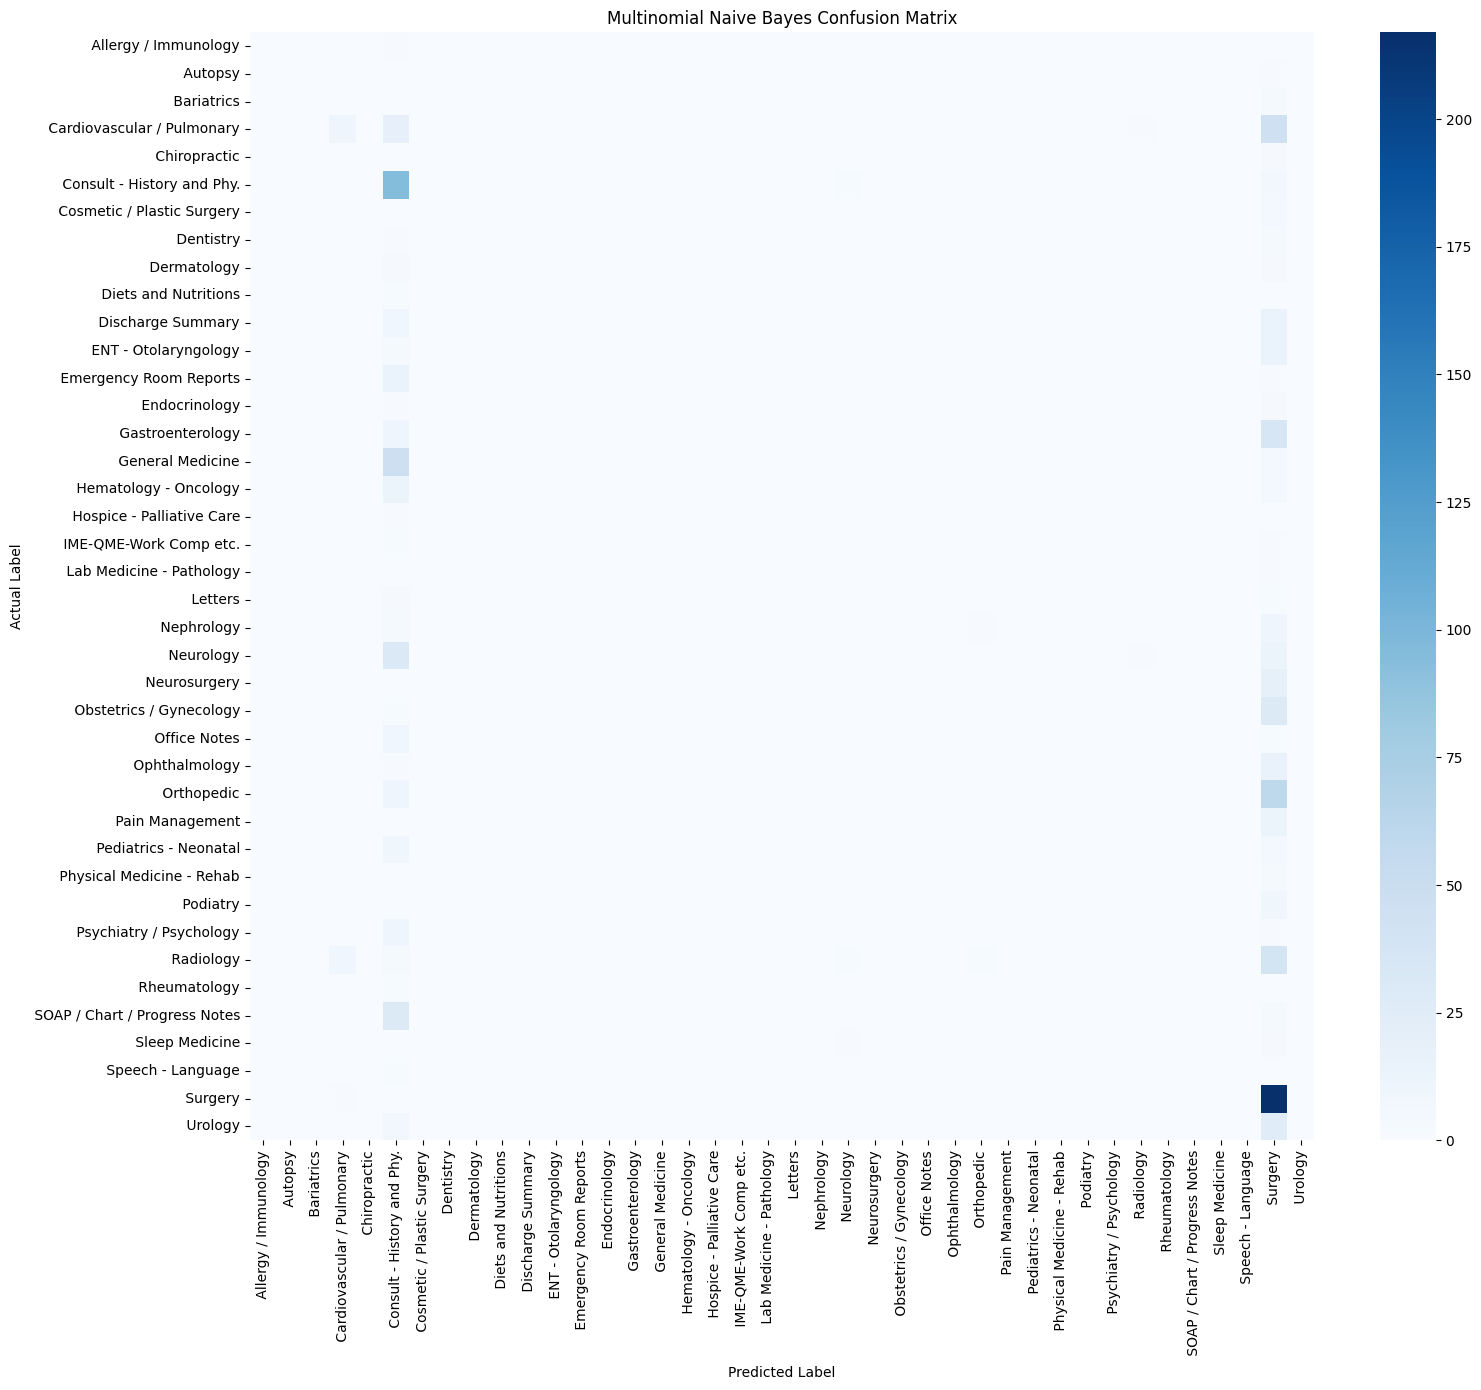

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm_nb,
    annot=False,
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
nb_path = f"{PROJECT_PATH}/naive_bayes_model.pkl"

joblib.dump(nb_model, nb_path)

print("Naive Bayes model saved successfully.")
print("Saved at:", nb_path)

Naive Bayes model saved successfully.
Saved at: /content/drive/MyDrive/MINI Project ML/naive_bayes_model.pkl


In [ ]:
# ============================================================
# Balanced SVM
# ============================================================

from sklearn.svm import LinearSVC

balanced_svm = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)

print("Balanced SVM model created successfully.")

Balanced SVM model created successfully.


In [ ]:
# Train Balanced SVM

print("Training Balanced SVM...")

balanced_svm.fit(X_train_tfidf, y_train)

print("Balanced SVM trained successfully.")

Training Balanced SVM...
Balanced SVM trained successfully.


In [ ]:
# Balanced SVM Predictions

y_pred_balanced_svm = balanced_svm.predict(X_test_tfidf)

print("Balanced SVM predictions completed successfully.")

Balanced SVM predictions completed successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_balanced_svm)

macro_precision = precision_score(
    y_test,
    y_pred_balanced_svm,
    average='macro',
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred_balanced_svm,
    average='macro',
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred_balanced_svm,
    average='macro',
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred_balanced_svm,
    average='weighted',
    zero_division=0
)

print("Balanced SVM Performance")
print("------------------------")
print("Accuracy       :", round(accuracy, 4))
print("Macro Precision:", round(macro_precision, 4))
print("Macro Recall   :", round(macro_recall, 4))
print("Macro F1       :", round(macro_f1, 4))
print("Weighted F1    :", round(weighted_f1, 4))

Balanced SVM Performance
------------------------
Accuracy       : 0.1007
Macro Precision: 0.1267
Macro Recall   : 0.181
Macro F1       : 0.1412
Weighted F1    : 0.0953


In [ ]:
print("Balanced SVM Classification Report")
print("-----------------------------------")

print(classification_report(
    y_test,
    y_pred_balanced_svm,
    zero_division=0
))

Balanced SVM Classification Report
-----------------------------------
                                precision    recall  f1-score   support

          Allergy / Immunology       0.17      1.00      0.29         1
                       Autopsy       1.00      1.00      1.00         1
                    Bariatrics       0.00      0.00      0.00         4
    Cardiovascular / Pulmonary       0.16      0.16      0.16        74
                  Chiropractic       0.00      0.00      0.00         3
    Consult - History and Phy.       0.08      0.07      0.07       103
    Cosmetic / Plastic Surgery       0.14      0.20      0.17         5
                     Dentistry       0.17      0.20      0.18         5
                   Dermatology       0.00      0.00      0.00         6
          Diets and Nutritions       0.00      0.00      0.00         2
             Discharge Summary       0.20      0.14      0.16        22
          ENT - Otolaryngology       0.06      0.05      0.06   

In [ ]:
# ============================================================
# Balanced Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

balanced_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

print("Balanced Logistic Regression model created successfully.")

Balanced Logistic Regression model created successfully.


In [ ]:
# Train Balanced Logistic Regression

print("Training Balanced Logistic Regression...")

balanced_lr.fit(X_train_tfidf, y_train)

print("Balanced Logistic Regression trained successfully.")

Training Balanced Logistic Regression...
Balanced Logistic Regression trained successfully.


In [ ]:
# Balanced Logistic Regression Predictions

y_pred_balanced_lr = balanced_lr.predict(X_test_tfidf)

print("Balanced Logistic Regression predictions completed successfully.")

Balanced Logistic Regression predictions completed successfully.


In [ ]:
accuracy = accuracy_score(y_test, y_pred_balanced_lr)

macro_precision = precision_score(
    y_test,
    y_pred_balanced_lr,
    average='macro',
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred_balanced_lr,
    average='macro',
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred_balanced_lr,
    average='macro',
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred_balanced_lr,
    average='weighted',
    zero_division=0
)

print("Balanced Logistic Regression Performance")
print("-----------------------------------------")
print("Accuracy       :", round(accuracy, 4))
print("Macro Precision:", round(macro_precision, 4))
print("Macro Recall   :", round(macro_recall, 4))
print("Macro F1       :", round(macro_f1, 4))
print("Weighted F1    :", round(weighted_f1, 4))

Balanced Logistic Regression Performance
-----------------------------------------
Accuracy       : 0.2739
Macro Precision: 0.2463
Macro Recall   : 0.3711
Macro F1       : 0.2825
Weighted F1    : 0.2392


In [ ]:
print("Balanced Logistic Regression Classification Report")
print("---------------------------------------------------")

print(classification_report(
    y_test,
    y_pred_balanced_lr,
    zero_division=0
))

Balanced Logistic Regression Classification Report
---------------------------------------------------
                                precision    recall  f1-score   support

          Allergy / Immunology       0.17      1.00      0.29         1
                       Autopsy       1.00      1.00      1.00         1
                    Bariatrics       0.00      0.00      0.00         4
    Cardiovascular / Pulmonary       0.30      0.32      0.31        74
                  Chiropractic       0.00      0.00      0.00         3
    Consult - History and Phy.       0.09      0.05      0.06       103
    Cosmetic / Plastic Surgery       0.14      0.20      0.17         5
                     Dentistry       0.38      0.60      0.46         5
                   Dermatology       0.00      0.00      0.00         6
          Diets and Nutritions       0.25      0.50      0.33         2
             Discharge Summary       0.48      0.55      0.51        22
          ENT - Otolaryngology  

In [ ]:
# ============================================================
# Weighted Multinomial Naive Bayes
# ============================================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.utils.class_weight import compute_sample_weight

nb_balanced = MultinomialNB()

print("Weighted Multinomial Naive Bayes model created successfully.")

Weighted Multinomial Naive Bayes model created successfully.


In [ ]:
# Calculate sample weights based on class frequency

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

print("Balanced sample weights calculated successfully.")
print("Minimum sample weight:", round(sample_weights.min(), 4))
print("Maximum sample weight:", round(sample_weights.max(), 4))

Balanced sample weights calculated successfully.
Minimum sample weight: 0.1141
Maximum sample weight: 19.855


In [ ]:
# Train Weighted Multinomial Naive Bayes

print("Training Weighted Multinomial Naive Bayes...")

nb_balanced.fit(
    X_train_tfidf,
    y_train,
    sample_weight=sample_weights
)

print("Weighted Multinomial Naive Bayes trained successfully.")

Training Weighted Multinomial Naive Bayes...
Weighted Multinomial Naive Bayes trained successfully.


In [ ]:
# Make predictions

y_pred_nb_balanced = nb_balanced.predict(X_test_tfidf)

print("Weighted Naive Bayes predictions completed successfully.")

Weighted Naive Bayes predictions completed successfully.


In [ ]:
accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb_balanced
)

precision_nb = precision_score(
    y_test,
    y_pred_nb_balanced,
    average='macro',
    zero_division=0
)

recall_nb = recall_score(
    y_test,
    y_pred_nb_balanced,
    average='macro',
    zero_division=0
)

f1_nb = f1_score(
    y_test,
    y_pred_nb_balanced,
    average='macro',
    zero_division=0
)

weighted_f1_nb = f1_score(
    y_test,
    y_pred_nb_balanced,
    average='weighted',
    zero_division=0
)

print("Weighted Multinomial Naive Bayes Performance")
print("----------------------------------------------")
print("Accuracy       :", round(accuracy_nb, 4))
print("Macro Precision:", round(precision_nb, 4))
print("Macro Recall   :", round(recall_nb, 4))
print("Macro F1       :", round(f1_nb, 4))
print("Weighted F1    :", round(weighted_f1_nb, 4))

Weighted Multinomial Naive Bayes Performance
----------------------------------------------
Accuracy       : 0.2709
Macro Precision: 0.2849
Macro Recall   : 0.5502
Macro F1       : 0.3415
Weighted F1    : 0.2271


In [ ]:
print("Weighted Multinomial Naive Bayes Classification Report")
print("-------------------------------------------------------")

print(classification_report(
    y_test,
    y_pred_nb_balanced,
    zero_division=0
))

Weighted Multinomial Naive Bayes Classification Report
-------------------------------------------------------
                                precision    recall  f1-score   support

          Allergy / Immunology       0.07      1.00      0.13         1
                       Autopsy       1.00      1.00      1.00         1
                    Bariatrics       0.29      0.50      0.36         4
    Cardiovascular / Pulmonary       0.32      0.27      0.29        74
                  Chiropractic       0.07      0.33      0.11         3
    Consult - History and Phy.       0.12      0.04      0.06       103
    Cosmetic / Plastic Surgery       0.12      0.60      0.19         5
                     Dentistry       0.25      0.60      0.35         5
                   Dermatology       0.33      0.33      0.33         6
          Diets and Nutritions       0.29      1.00      0.44         2
             Discharge Summary       0.50      0.55      0.52        22
          ENT - Otolaryn

In [ ]:
import pandas as pd

print("Pandas imported successfully.")

Pandas imported successfully.


In [ ]:
# Model Performance Comparison

model_results = pd.DataFrame({
    "Model": [
        "SVM",
        "Logistic Regression",
        "Random Forest",
        "Balanced SVM",
        "Balanced Logistic Regression",
        "Weighted Multinomial Naive Bayes"
    ],
    "Accuracy": [
        0.1067,
        0.2296,
        0.0785,
        0.1007,
        0.2739,
        0.2709
    ],
    "Macro Precision": [
        0.0666,
        0.0310,
        0.0442,
        0.1267,
        0.2463,
        0.2849
    ],
    "Macro Recall": [
        0.0535,
        0.0441,
        0.0324,
        0.1810,
        0.3711,
        0.5502
    ],
    "Macro F1": [
        0.0539,
        0.0348,
        0.0359,
        0.1412,
        0.2825,
        0.3415
    ],
    "Weighted F1": [
        0.0972,
        0.1676,
        0.0734,
        0.0953,
        0.2392,
        0.2271
    ]
})

model_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,SVM,0.1067,0.0666,0.0535,0.0539,0.0972
1,Logistic Regression,0.2296,0.0310,0.0441,0.0348,0.1676
2,Random Forest,0.0785,0.0442,0.0324,0.0359,0.0734
3,Balanced SVM,0.1007,0.1267,0.1810,0.1412,0.0953
4,Balanced Logistic Regression,0.2739,0.2463,0.3711,0.2825,0.2392
5,Weighted Multinomial Naive Bayes,0.2709,0.2849,0.5502,0.3415,0.2271


In [ ]:
# Sort models by Macro F1

model_results.sort_values(
    by="Macro F1",
    ascending=False
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
5,Weighted Multinomial Naive Bayes,0.2709,0.2849,0.5502,0.3415,0.2271
4,Balanced Logistic Regression,0.2739,0.2463,0.3711,0.2825,0.2392
3,Balanced SVM,0.1007,0.1267,0.1810,0.1412,0.0953
0,SVM,0.1067,0.0666,0.0535,0.0539,0.0972
2,Random Forest,0.0785,0.0442,0.0324,0.0359,0.0734
1,Logistic Regression,0.2296,0.0310,0.0441,0.0348,0.1676


In [ ]:
from sklearn.ensemble import VotingClassifier

voting_ensemble = VotingClassifier(
    estimators=[
        ('lr', balanced_lr),
        ('nb', nb_balanced)
    ],
    voting='soft',
    weights=[1, 1],
    n_jobs=-1
)

print("Soft Voting Ensemble created successfully.")

Soft Voting Ensemble created successfully.


In [ ]:
print("Training Soft Voting Ensemble...")

voting_ensemble.fit(
    X_train_tfidf,
    y_train
)

print("Soft Voting Ensemble trained successfully.")

Training Soft Voting Ensemble...
Soft Voting Ensemble trained successfully.


In [ ]:
y_pred_ensemble = voting_ensemble.predict(X_test_tfidf)

print("Voting Ensemble predictions completed successfully.")

Voting Ensemble predictions completed successfully.


In [ ]:
ensemble_accuracy = accuracy_score(
    y_test,
    y_pred_ensemble
)

ensemble_precision = precision_score(
    y_test,
    y_pred_ensemble,
    average='macro',
    zero_division=0
)

ensemble_recall = recall_score(
    y_test,
    y_pred_ensemble,
    average='macro',
    zero_division=0
)

ensemble_f1 = f1_score(
    y_test,
    y_pred_ensemble,
    average='macro',
    zero_division=0
)

ensemble_weighted_f1 = f1_score(
    y_test,
    y_pred_ensemble,
    average='weighted',
    zero_division=0
)

print("Voting Ensemble Performance")
print("---------------------------")
print("Accuracy       :", round(ensemble_accuracy, 4))
print("Macro Precision:", round(ensemble_precision, 4))
print("Macro Recall   :", round(ensemble_recall, 4))
print("Macro F1       :", round(ensemble_f1, 4))
print("Weighted F1    :", round(ensemble_weighted_f1, 4))

Voting Ensemble Performance
---------------------------
Accuracy       : 0.3263
Macro Precision: 0.0555
Macro Recall   : 0.0588
Macro F1       : 0.0406
Weighted F1    : 0.184


In [ ]:
print("Voting Ensemble Classification Report")
print("--------------------------------------")

print(classification_report(
    y_test,
    y_pred_ensemble,
    zero_division=0
))

Voting Ensemble Classification Report
--------------------------------------
                                precision    recall  f1-score   support

          Allergy / Immunology       0.00      0.00      0.00         1
                       Autopsy       0.00      0.00      0.00         1
                    Bariatrics       0.00      0.00      0.00         4
    Cardiovascular / Pulmonary       0.42      0.14      0.20        74
                  Chiropractic       0.00      0.00      0.00         3
    Consult - History and Phy.       0.29      0.90      0.43       103
    Cosmetic / Plastic Surgery       0.00      0.00      0.00         5
                     Dentistry       0.00      0.00      0.00         5
                   Dermatology       0.00      0.00      0.00         6
          Diets and Nutritions       0.00      0.00      0.00         2
             Discharge Summary       0.00      0.00      0.00        22
          ENT - Otolaryngology       0.00      0.00      0

In [ ]:
# NB-heavy Soft Voting Ensemble

voting_ensemble_nb = VotingClassifier(
    estimators=[
        ('lr', balanced_lr),
        ('nb', nb_balanced)
    ],
    voting='soft',
    weights=[1, 3],
    n_jobs=-1
)

print("NB-heavy Voting Ensemble created successfully.")

NB-heavy Voting Ensemble created successfully.


In [ ]:
print("Training NB-heavy Voting Ensemble...")

voting_ensemble_nb.fit(
    X_train_tfidf,
    y_train
)

print("NB-heavy Voting Ensemble trained successfully.")

Training NB-heavy Voting Ensemble...
NB-heavy Voting Ensemble trained successfully.


In [ ]:
y_pred_ensemble_nb = voting_ensemble_nb.predict(X_test_tfidf)

print("NB-heavy Voting Ensemble predictions completed successfully.")

NB-heavy Voting Ensemble predictions completed successfully.


In [ ]:
ensemble_nb_accuracy = accuracy_score(
    y_test,
    y_pred_ensemble_nb
)

ensemble_nb_precision = precision_score(
    y_test,
    y_pred_ensemble_nb,
    average='macro',
    zero_division=0
)

ensemble_nb_recall = recall_score(
    y_test,
    y_pred_ensemble_nb,
    average='macro',
    zero_division=0
)

ensemble_nb_f1 = f1_score(
    y_test,
    y_pred_ensemble_nb,
    average='macro',
    zero_division=0
)

ensemble_nb_weighted_f1 = f1_score(
    y_test,
    y_pred_ensemble_nb,
    average='weighted',
    zero_division=0
)

print("NB-heavy Voting Ensemble Performance")
print("-------------------------------------")
print("Accuracy       :", round(ensemble_nb_accuracy, 4))
print("Macro Precision:", round(ensemble_nb_precision, 4))
print("Macro Recall   :", round(ensemble_nb_recall, 4))
print("Macro F1       :", round(ensemble_nb_f1, 4))
print("Weighted F1    :", round(ensemble_nb_weighted_f1, 4))

NB-heavy Voting Ensemble Performance
-------------------------------------
Accuracy       : 0.3263
Macro Precision: 0.0283
Macro Recall   : 0.0519
Macro F1       : 0.0295
Weighted F1    : 0.1759


In [ ]:
print("NB-heavy Voting Ensemble Classification Report")
print("------------------------------------------------")

print(classification_report(
    y_test,
    y_pred_ensemble_nb,
    zero_division=0
))

NB-heavy Voting Ensemble Classification Report
------------------------------------------------
                                precision    recall  f1-score   support

          Allergy / Immunology       0.00      0.00      0.00         1
                       Autopsy       0.00      0.00      0.00         1
                    Bariatrics       0.00      0.00      0.00         4
    Cardiovascular / Pulmonary       0.50      0.15      0.23        74
                  Chiropractic       0.00      0.00      0.00         3
    Consult - History and Phy.       0.28      0.93      0.43       103
    Cosmetic / Plastic Surgery       0.00      0.00      0.00         5
                     Dentistry       0.00      0.00      0.00         5
                   Dermatology       0.00      0.00      0.00         6
          Diets and Nutritions       0.00      0.00      0.00         2
             Discharge Summary       0.00      0.00      0.00        22
          ENT - Otolaryngology       0.

In [ ]:
from sklearn.ensemble import VotingClassifier

hard_voting_ensemble = VotingClassifier(
    estimators=[
        ('svm', balanced_svm),
        ('lr', balanced_lr),
        ('nb', nb_balanced)
    ],
    voting='hard',
    n_jobs=-1
)

print("Hard Voting Ensemble created successfully.")

Hard Voting Ensemble created successfully.


In [ ]:
print("Training Hard Voting Ensemble...")

hard_voting_ensemble.fit(
    X_train_tfidf,
    y_train
)

print("Hard Voting Ensemble trained successfully.")

Training Hard Voting Ensemble...
Hard Voting Ensemble trained successfully.


In [ ]:
y_pred_hard = hard_voting_ensemble.predict(X_test_tfidf)

print("Hard Voting Ensemble predictions completed successfully.")

Hard Voting Ensemble predictions completed successfully.


In [ ]:
hard_accuracy = accuracy_score(
    y_test,
    y_pred_hard
)

hard_precision = precision_score(
    y_test,
    y_pred_hard,
    average='macro',
    zero_division=0
)

hard_recall = recall_score(
    y_test,
    y_pred_hard,
    average='macro',
    zero_division=0
)

hard_f1 = f1_score(
    y_test,
    y_pred_hard,
    average='macro',
    zero_division=0
)

hard_weighted_f1 = f1_score(
    y_test,
    y_pred_hard,
    average='weighted',
    zero_division=0
)

print("Hard Voting Ensemble Performance")
print("---------------------------------")
print("Accuracy       :", round(hard_accuracy, 4))
print("Macro Precision:", round(hard_precision, 4))
print("Macro Recall   :", round(hard_recall, 4))
print("Macro F1       :", round(hard_f1, 4))
print("Weighted F1    :", round(hard_weighted_f1, 4))

Hard Voting Ensemble Performance
---------------------------------
Accuracy       : 0.1198
Macro Precision: 0.1172
Macro Recall   : 0.1549
Macro F1       : 0.1259
Weighted F1    : 0.1145


In [ ]:
print("Hard Voting Ensemble Classification Report")
print("--------------------------------------------")

print(classification_report(
    y_test,
    y_pred_hard,
    zero_division=0
))

Hard Voting Ensemble Classification Report
--------------------------------------------
                                precision    recall  f1-score   support

          Allergy / Immunology       0.17      1.00      0.29         1
                       Autopsy       1.00      1.00      1.00         1
                    Bariatrics       0.00      0.00      0.00         4
    Cardiovascular / Pulmonary       0.16      0.15      0.15        74
                  Chiropractic       0.00      0.00      0.00         3
    Consult - History and Phy.       0.12      0.15      0.13       103
    Cosmetic / Plastic Surgery       0.00      0.00      0.00         5
                     Dentistry       0.17      0.20      0.18         5
                   Dermatology       0.00      0.00      0.00         6
          Diets and Nutritions       0.00      0.00      0.00         2
             Discharge Summary       0.37      0.32      0.34        22
          ENT - Otolaryngology       0.06      

In [ ]:
# ============================================================
# Systematic Soft Voting Weight Comparison
# ============================================================

weight_results = []

weight_combinations = [
    (1, 1),
    (1, 2),
    (1, 3),
    (1, 4),
    (2, 1),
    (3, 1),
    (4, 1)
]

for lr_weight, nb_weight in weight_combinations:

    model = VotingClassifier(
        estimators=[
            ('lr', balanced_lr),
            ('nb', nb_balanced)
        ],
        voting='soft',
        weights=[lr_weight, nb_weight],
        n_jobs=-1
    )

    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, predictions)

    macro_precision = precision_score(
        y_test,
        predictions,
        average='macro',
        zero_division=0
    )

    macro_recall = recall_score(
        y_test,
        predictions,
        average='macro',
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average='macro',
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average='weighted',
        zero_division=0
    )

    weight_results.append({
        "LR Weight": lr_weight,
        "NB Weight": nb_weight,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })

weight_results_df = pd.DataFrame(weight_results)

weight_results_df = weight_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("Soft Voting Weight Comparison")
print("=============================")

display(weight_results_df)

Soft Voting Weight Comparison


,LR Weight,NB Weight,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,4,1,0.287009,0.100022,0.122331,0.100732,0.205694
1,3,1,0.289023,0.073650,0.083201,0.069079,0.190267
2,2,1,0.308157,0.062381,0.062904,0.046855,0.184118
3,1,1,0.326284,0.055534,0.058802,0.040631,0.183973
4,1,2,0.327291,0.040932,0.052709,0.031159,0.178896
5,1,4,0.326284,0.028856,0.051903,0.029515,0.175745
6,1,3,0.326284,0.028284,0.051903,0.029477,0.175875
